# 05 — Digital Simulation

5.1 Ancilla circuit for single-spin decay

5.2 Validate decay for an arbitrary quantum state

5.3 Build the Hamiltonian evolution circuit

5.4 Construct one complete MSSE circuit step

5.5 Repeat the circuit over time

5.6 Validate against Notebook 04


5.1 Ancilla Circuit for single-spin decay

In [2]:
%pip install qiskit qiskit-aer
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


EXERCISE 5.1 — ANCILLA DECAY
-----------------------------
gamma              = 0.5
dt                 = 0.4
gamma * dt         = 0.2
theta              = 0.927295 rad

FINAL STATEVECTOR
-----------------
[0.894427+0.j 0.      +0.j 0.      +0.j 0.447214+0.j]

BASIS PROBABILITIES
-------------------
|00> : 0.800000
|11> : 0.200000

DECAY VALIDATION
----------------
Expected jump probability = 0.200000
Circuit jump probability  = 0.200000
No-jump probability       = 0.800000
Absolute error            = 2.78e-17


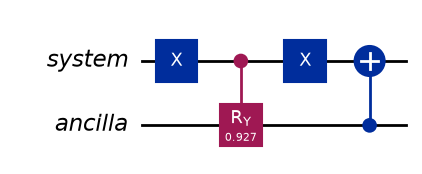

In [1]:
# Exercise 5.1 — Ancilla circuit for single-spin decay

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector


# ------------------------------------------------------------
# 1. Parameters from Notebook 04 / paper
# ------------------------------------------------------------

gamma = 0.5

# Paper uses gamma * dt = 0.2
gamma_dt = 0.2
dt = gamma_dt / gamma

# Jump probability during one timestep
p_jump_expected = gamma * dt

# Rotation angle from the paper:
#
# sin^2(theta/2) = gamma * dt
#
theta = 2 * np.arcsin(
    np.sqrt(p_jump_expected)
)


# ------------------------------------------------------------
# 2. Create system and ancilla qubits
#
# Our convention:
#
# |0> = spin up   = excited
# |1> = spin down = decayed
# ------------------------------------------------------------

system = QuantumRegister(
    1,
    "system"
)

ancilla = QuantumRegister(
    1,
    "ancilla"
)

qc_decay = QuantumCircuit(
    system,
    ancilla
)


# Initial state is already |0>|0>
#
# system  = |0> = up
# ancilla = |0>


# ------------------------------------------------------------
# 3. Control the ancilla rotation on system = |0>
#
# Qiskit's controlled gates normally activate when the
# control qubit is |1>.
#
# Therefore:
#
# X -> controlled Ry -> X
#
# lets us control on |0>.
# ------------------------------------------------------------

qc_decay.x(
    system[0]
)

qc_decay.cry(
    theta,
    system[0],
    ancilla[0]
)

qc_decay.x(
    system[0]
)


# ------------------------------------------------------------
# 4. Convert ancilla excitation into physical decay
#
# If ancilla = 1:
#
# system |0> -> |1>
#
# Therefore ancilla = 1 records that a jump occurred.
# ------------------------------------------------------------

qc_decay.cx(
    ancilla[0],
    system[0]
)


# ------------------------------------------------------------
# 5. Obtain statevector before measurement
# ------------------------------------------------------------

final_state = Statevector.from_instruction(
    qc_decay
)

probabilities = (
    final_state.probabilities_dict()
)


# ------------------------------------------------------------
# 6. Print parameters
# ------------------------------------------------------------

print("EXERCISE 5.1 — ANCILLA DECAY")
print("-----------------------------")

print(f"gamma              = {gamma}")
print(f"dt                 = {dt}")
print(f"gamma * dt         = {gamma * dt}")
print(f"theta              = {theta:.6f} rad")

print("\nFINAL STATEVECTOR")
print("-----------------")

print(
    np.round(
        final_state.data,
        6
    )
)


# ------------------------------------------------------------
# 7. Display basis probabilities
#
# Qiskit prints basis states as:
#
# |ancilla system>
# ------------------------------------------------------------

print("\nBASIS PROBABILITIES")
print("-------------------")

for state, probability in probabilities.items():

    print(
        f"|{state}> : "
        f"{probability:.6f}"
    )


# ------------------------------------------------------------
# 8. Extract jump probability
#
# ancilla = 1 means jump occurred.
# ------------------------------------------------------------

p_jump_circuit = sum(
    probability
    for state, probability
    in probabilities.items()
    if state[0] == "1"
)

p_no_jump_circuit = (
    1.0 - p_jump_circuit
)


# ------------------------------------------------------------
# 9. Validation
# ------------------------------------------------------------

probability_error = abs(
    p_jump_circuit
    - p_jump_expected
)


print("\nDECAY VALIDATION")
print("----------------")

print(
    f"Expected jump probability = "
    f"{p_jump_expected:.6f}"
)

print(
    f"Circuit jump probability  = "
    f"{p_jump_circuit:.6f}"
)

print(
    f"No-jump probability       = "
    f"{p_no_jump_circuit:.6f}"
)

print(
    f"Absolute error            = "
    f"{probability_error:.2e}"
)


# ------------------------------------------------------------
# 10. Draw circuit
# ------------------------------------------------------------

display(
    qc_decay.draw(
        output="mpl"
    )
)

5.2 Validate decay for an arbitrary quantum state

In [2]:
# Exercise 5.2 — Validate decay for an arbitrary quantum state

import numpy as np

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector


# ------------------------------------------------------------
# 1. Use the same decay parameters as Exercise 5.1
# ------------------------------------------------------------

gamma = 0.5
dt = 0.4

p_decay = gamma * dt

theta = 2 * np.arcsin(
    np.sqrt(p_decay)
)


# ------------------------------------------------------------
# 2. Define an arbitrary normalised input state
#
# |psi> = alpha|0> + beta|1>
#
# Our convention:
#
# |0> = up / excited
# |1> = down / ground
# ------------------------------------------------------------

alpha = np.sqrt(0.6)

beta = (
    np.exp(1j * 0.4)
    * np.sqrt(0.4)
)

psi_input = np.array(
    [alpha, beta],
    dtype=complex
)

psi_input = (
    psi_input
    / np.linalg.norm(psi_input)
)


print("INPUT STATE")
print("-----------")

print(
    np.round(
        psi_input,
        6
    )
)

print(
    f"Norm = "
    f"{np.linalg.norm(psi_input):.6f}"
)


# ------------------------------------------------------------
# 3. Build system + ancilla circuit
# ------------------------------------------------------------

system = QuantumRegister(
    1,
    "system"
)

ancilla = QuantumRegister(
    1,
    "ancilla"
)

qc = QuantumCircuit(
    system,
    ancilla
)


# ------------------------------------------------------------
# 4. Prepare arbitrary system state
# ------------------------------------------------------------

qc.initialize(
    psi_input,
    system[0]
)


# ------------------------------------------------------------
# 5. Apply the decay circuit
#
# Control ancilla rotation on system = |0>
# ------------------------------------------------------------

qc.x(
    system[0]
)

qc.cry(
    theta,
    system[0],
    ancilla[0]
)

qc.x(
    system[0]
)


# If ancilla = 1, flip system:
#
# |0> -> |1>
#
qc.cx(
    ancilla[0],
    system[0]
)


# ------------------------------------------------------------
# 6. Obtain the complete joint statevector
# ------------------------------------------------------------

final_state = Statevector.from_instruction(
    qc
)

statevector = final_state.data


print("\nFINAL JOINT STATEVECTOR")
print("-----------------------")

print(
    np.round(
        statevector,
        6
    )
)


# ------------------------------------------------------------
# 7. Analytical prediction
#
# Circuit should produce:
#
# alpha sqrt(1-p)|0>|0_a>
# + beta            |1>|0_a>
# + alpha sqrt(p)   |1>|1_a>
#
# Qiskit basis ordering is:
#
# |ancilla system>
#
# Therefore amplitudes are:
#
# |00> : alpha sqrt(1-p)
# |01> : beta
# |10> : 0
# |11> : alpha sqrt(p)
# ------------------------------------------------------------

expected_state = np.array(
    [
        alpha * np.sqrt(1 - p_decay),
        beta,
        0,
        alpha * np.sqrt(p_decay)
    ],
    dtype=complex
)


print("\nEXPECTED JOINT STATEVECTOR")
print("--------------------------")

print(
    np.round(
        expected_state,
        6
    )
)


# ------------------------------------------------------------
# 8. Statevector validation
# ------------------------------------------------------------

state_error = np.linalg.norm(
    statevector
    - expected_state
)


print("\nSTATEVECTOR VALIDATION")
print("----------------------")

print(
    f"Statevector error = "
    f"{state_error:.2e}"
)


# ------------------------------------------------------------
# 9. Expected jump probability
#
# Only the excited |0> component can decay.
#
# P_jump = |alpha|^2 * gamma * dt
# ------------------------------------------------------------

p_jump_expected = (
    np.abs(alpha)**2
    * p_decay
)

p_no_jump_expected = (
    1.0
    - p_jump_expected
)


# ------------------------------------------------------------
# 10. Extract probabilities from circuit
# ------------------------------------------------------------

probabilities = (
    final_state.probabilities_dict()
)

p_jump_circuit = sum(
    probability
    for state, probability
    in probabilities.items()
    if state[0] == "1"
)

p_no_jump_circuit = (
    1.0
    - p_jump_circuit
)


print("\nJUMP PROBABILITY")
print("----------------")

print(
    f"Excited-state population = "
    f"{np.abs(alpha)**2:.6f}"
)

print(
    f"Expected jump probability = "
    f"{p_jump_expected:.6f}"
)

print(
    f"Circuit jump probability  = "
    f"{p_jump_circuit:.6f}"
)

print(
    f"Expected no-jump prob.     = "
    f"{p_no_jump_expected:.6f}"
)

print(
    f"Circuit no-jump prob.      = "
    f"{p_no_jump_circuit:.6f}"
)


# ------------------------------------------------------------
# 11. Construct analytical conditional states
# ------------------------------------------------------------

# NO-JUMP branch:
#
# alpha sqrt(1-p)|0> + beta|1>
#
psi_no_jump_expected = np.array(
    [
        alpha * np.sqrt(1 - p_decay),
        beta
    ],
    dtype=complex
)

psi_no_jump_expected /= (
    np.linalg.norm(
        psi_no_jump_expected
    )
)


# JUMP branch:
#
# decay sends excited |0> -> ground |1>
#
psi_jump_expected = np.array(
    [0, 1],
    dtype=complex
)


print("\nEXPECTED CONDITIONAL STATES")
print("---------------------------")

print("No-jump state:")

print(
    np.round(
        psi_no_jump_expected,
        6
    )
)

print("\nJump state:")

print(
    np.round(
        psi_jump_expected,
        6
    )
)


# ------------------------------------------------------------
# 12. Extract conditional states from joint statevector
#
# Qiskit ordering:
#
# [|00>, |01>, |10>, |11>]
#
# ancilla = 0:
#     |00>, |01>
#
# ancilla = 1:
#     |10>, |11>
# ------------------------------------------------------------

psi_no_jump_circuit = np.array(
    [
        statevector[0],
        statevector[1]
    ],
    dtype=complex
)

psi_jump_circuit = np.array(
    [
        statevector[2],
        statevector[3]
    ],
    dtype=complex
)


# Normalise conditional branches
psi_no_jump_circuit /= (
    np.linalg.norm(
        psi_no_jump_circuit
    )
)

psi_jump_circuit /= (
    np.linalg.norm(
        psi_jump_circuit
    )
)


print("\nCIRCUIT CONDITIONAL STATES")
print("--------------------------")

print("No-jump state:")

print(
    np.round(
        psi_no_jump_circuit,
        6
    )
)

print("\nJump state:")

print(
    np.round(
        psi_jump_circuit,
        6
    )
)


# ------------------------------------------------------------
# 13. Compare conditional states
# ------------------------------------------------------------

no_jump_error = np.linalg.norm(
    psi_no_jump_circuit
    - psi_no_jump_expected
)

jump_error = np.linalg.norm(
    psi_jump_circuit
    - psi_jump_expected
)


print("\nCONDITIONAL STATE VALIDATION")
print("----------------------------")

print(
    f"No-jump state error = "
    f"{no_jump_error:.2e}"
)

print(
    f"Jump state error    = "
    f"{jump_error:.2e}"
)


# ------------------------------------------------------------
# 14. Final validation summary
# ------------------------------------------------------------

print("\nEXERCISE 5.2 SUMMARY")
print("--------------------")

print(
    f"Joint-state error      : "
    f"{state_error:.2e}"
)

print(
    f"Jump-probability error : "
    f"{abs(p_jump_circuit - p_jump_expected):.2e}"
)

print(
    f"No-jump branch error   : "
    f"{no_jump_error:.2e}"
)

print(
    f"Jump branch error      : "
    f"{jump_error:.2e}"
)

print(
    "\nExercise 5.2 complete."
)

INPUT STATE
-----------
[0.774597+0.j      0.58253 +0.24629j]
Norm = 1.000000

FINAL JOINT STATEVECTOR
-----------------------
[0.69282+0.j      0.58253+0.24629j 0.     +0.j      0.34641+0.j     ]

EXPECTED JOINT STATEVECTOR
--------------------------
[0.69282+0.j      0.58253+0.24629j 0.     +0.j      0.34641+0.j     ]

STATEVECTOR VALIDATION
----------------------
Statevector error = 0.00e+00

JUMP PROBABILITY
----------------
Excited-state population = 0.600000
Expected jump probability = 0.120000
Circuit jump probability  = 0.120000
Expected no-jump prob.     = 0.880000
Circuit no-jump prob.      = 0.880000

EXPECTED CONDITIONAL STATES
---------------------------
No-jump state:
[0.738549+0.j       0.620979+0.262546j]

Jump state:
[0.+0.j 1.+0.j]

CIRCUIT CONDITIONAL STATES
--------------------------
No-jump state:
[0.738549+0.j       0.620979+0.262546j]

Jump state:
[0.+0.j 1.+0.j]

CONDITIONAL STATE VALIDATION
----------------------------
No-jump state error = 0.00e+00
Jump state 

5.3 Build the Hamiltonian evolution circuit

EXERCISE 5.3 — HAMILTONIAN CIRCUIT
-----------------------------------
J                  = 1.0
Delta              = 1.0
dt                 = 0.4
Half-step Rx angle = 0.400000 rad
RZZ angle          = -0.800000 rad

Raw unitary difference = 8.067903e-02

STATE COMPARISON
----------------
Exact state:
[ 0.773513+0.369089j  0.      -0.34876j   0.      -0.34876j
 -0.147548-0.020329j]

Trotter state:
[ 0.781385+0.389418j  0.      -0.330364j  0.      -0.330364j
 -0.139676-0.j      ]

State fidelity = 0.99847299
State error    = 4.033951e-02

MAGNETISATION AFTER ONE STEP
----------------------------
Exact <Mz>   = 0.71236599
Trotter <Mz> = 0.74270012
Difference   = 3.03e-02


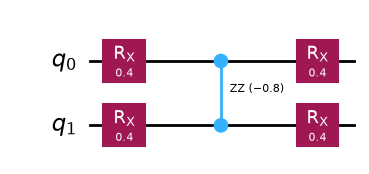

In [3]:
# Exercise 5.3 — Trotterised Hamiltonian circuit

from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator


# ------------------------------------------------------------
# 1. DTI parameters
# ------------------------------------------------------------

J = 1.0
Delta = 1.0

# Keep the same timestep as Notebook 04
dt = 0.4


# ------------------------------------------------------------
# 2. NumPy operators for exact reference
# ------------------------------------------------------------

I = np.eye(2, dtype=complex)

X = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)

Z = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)


X1 = np.kron(X, I)
X2 = np.kron(I, X)

ZZ = np.kron(Z, Z)


# Full two-spin Hamiltonian
H = (
    -J * ZZ
    + Delta * (X1 + X2)
)


# ------------------------------------------------------------
# 3. Exact one-step unitary
# ------------------------------------------------------------

U_exact = expm(
    -1j * H * dt
)


# ------------------------------------------------------------
# 4. Build symmetric Trotter circuit
#
# exp(-i H dt)
#
# ≈
#
# exp(-i H_X dt/2)
# exp(-i H_ZZ dt)
# exp(-i H_X dt/2)
#
# ------------------------------------------------------------

qc_H = QuantumCircuit(
    2,
    name="DTI Hamiltonian"
)


# ------------------------------------------------------------
# First half-step of transverse field
#
# Rx(theta) = exp(-i theta X / 2)
#
# We need:
#
# exp[-i Delta X (dt/2)]
#
# therefore:
#
# theta = Delta * dt
# ------------------------------------------------------------

theta_x_half = (
    Delta * dt
)

qc_H.rx(
    theta_x_half,
    0
)

qc_H.rx(
    theta_x_half,
    1
)


# ------------------------------------------------------------
# Full ZZ interaction
#
# RZZ(theta) = exp(-i theta ZZ / 2)
#
# We need:
#
# exp[-i (-J ZZ) dt]
# =
# exp[+i J ZZ dt]
#
# therefore:
#
# theta_ZZ = -2 J dt
# ------------------------------------------------------------

theta_zz = (
    -2 * J * dt
)

qc_H.rzz(
    theta_zz,
    0,
    1
)


# ------------------------------------------------------------
# Final half-step of transverse field
# ------------------------------------------------------------

qc_H.rx(
    theta_x_half,
    0
)

qc_H.rx(
    theta_x_half,
    1
)


# ------------------------------------------------------------
# 5. Obtain circuit unitary
# ------------------------------------------------------------

U_trotter = Operator(
    qc_H
).data


# ------------------------------------------------------------
# 6. Compare exact and Trotter unitaries
#
# Global phase does not affect physical predictions,
# so we compare their action on a state below as well.
# ------------------------------------------------------------

unitary_difference = np.linalg.norm(
    U_exact
    - U_trotter
)


print("EXERCISE 5.3 — HAMILTONIAN CIRCUIT")
print("-----------------------------------")

print(
    f"J                  = {J}"
)

print(
    f"Delta              = {Delta}"
)

print(
    f"dt                 = {dt}"
)

print(
    f"Half-step Rx angle = "
    f"{theta_x_half:.6f} rad"
)

print(
    f"RZZ angle          = "
    f"{theta_zz:.6f} rad"
)

print(
    f"\nRaw unitary difference = "
    f"{unitary_difference:.6e}"
)


# ------------------------------------------------------------
# 7. Test on the fully-up initial state
#
# Notebook convention:
#
# |up up> = |00>
# ------------------------------------------------------------

psi0 = np.array(
    [1, 0, 0, 0],
    dtype=complex
)


psi_exact = (
    U_exact @ psi0
)

psi_trotter = (
    U_trotter @ psi0
)


# ------------------------------------------------------------
# 8. State fidelity
#
# F = |<psi_exact | psi_trotter>|^2
# ------------------------------------------------------------

state_fidelity = (
    np.abs(
        np.vdot(
            psi_exact,
            psi_trotter
        )
    )**2
)


state_error = np.linalg.norm(
    psi_exact
    - psi_trotter
)


print("\nSTATE COMPARISON")
print("----------------")

print("Exact state:")

print(
    np.round(
        psi_exact,
        6
    )
)

print("\nTrotter state:")

print(
    np.round(
        psi_trotter,
        6
    )
)

print(
    f"\nState fidelity = "
    f"{state_fidelity:.8f}"
)

print(
    f"State error    = "
    f"{state_error:.6e}"
)


# ------------------------------------------------------------
# 9. Magnetisation comparison
# ------------------------------------------------------------

Mz = (
    np.kron(Z, I)
    + np.kron(I, Z)
) / 2


Mz_exact_step = np.real(
    np.vdot(
        psi_exact,
        Mz @ psi_exact
    )
)

Mz_trotter_step = np.real(
    np.vdot(
        psi_trotter,
        Mz @ psi_trotter
    )
)


print("\nMAGNETISATION AFTER ONE STEP")
print("----------------------------")

print(
    f"Exact <Mz>   = "
    f"{Mz_exact_step:.8f}"
)

print(
    f"Trotter <Mz> = "
    f"{Mz_trotter_step:.8f}"
)

print(
    f"Difference   = "
    f"{abs(Mz_exact_step - Mz_trotter_step):.2e}"
)


# ------------------------------------------------------------
# 10. Draw the circuit
# ------------------------------------------------------------

display(
    qc_H.draw(
        output="mpl"
    )
)

5.4 Construct one complete MSSE circuit step

In [4]:
# Exercise 5.4 — One complete digital MSSE step

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# ------------------------------------------------------------
# 1. Parameters
# ------------------------------------------------------------

J = 1.0
Delta = 1.0
gamma = 0.5
dt = 0.4

# Initial optimised value from Notebook 04 / paper
x_step = 0.4906

# Decay rotation
p_decay = gamma * dt

theta_decay = 2 * np.arcsin(
    np.sqrt(p_decay)
)


# ------------------------------------------------------------
# 2. Helper function:
#    symmetric Trotter evolution for arbitrary time tau
#
# exp(-i H tau)
#
# ≈
#
# exp(-i H_X tau/2)
# exp(-i H_ZZ tau)
# exp(-i H_X tau/2)
# ------------------------------------------------------------

def append_dti_trotter(
    circuit,
    q0,
    q1,
    tau
):
    """
    Append one symmetric Trotter approximation to
    exp(-i H tau) for the two-spin DTI Hamiltonian.
    """

    # Half transverse-field evolution
    theta_x = Delta * tau

    circuit.rx(
        theta_x,
        q0
    )

    circuit.rx(
        theta_x,
        q1
    )

    # Full Ising ZZ interaction
    theta_zz = -2 * J * tau

    circuit.rzz(
        theta_zz,
        q0,
        q1
    )

    # Final half transverse-field evolution
    circuit.rx(
        theta_x,
        q0
    )

    circuit.rx(
        theta_x,
        q1
    )


# ------------------------------------------------------------
# 3. Helper function:
#    ancilla-assisted decay on one system qubit
#
# Our convention:
#
# |0> = spin up   = excited
# |1> = spin down = decayed
# ------------------------------------------------------------

def append_decay_channel(
    circuit,
    system_qubit,
    ancilla_qubit,
    classical_bit
):
    """
    Apply one ancilla-assisted amplitude-decay channel,
    measure the ancilla, then reset it for reuse.
    """

    # Control Ry on system = |0>
    circuit.x(
        system_qubit
    )

    circuit.cry(
        theta_decay,
        system_qubit,
        ancilla_qubit
    )

    circuit.x(
        system_qubit
    )

    # ancilla = 1 causes physical decay
    circuit.cx(
        ancilla_qubit,
        system_qubit
    )

    # Record whether the jump occurred
    circuit.measure(
        ancilla_qubit,
        classical_bit
    )

    # Reuse the same ancilla
    circuit.reset(
        ancilla_qubit
    )


# ------------------------------------------------------------
# 4. Build one complete MSSE circuit step
#
# Qubits:
#
# q0 = system spin 1
# q1 = system spin 2
# q2 = ancilla
#
# Classical bits:
#
# c0 = jump on spin 1
# c1 = jump on spin 2
# c2 = final state of spin 1
# c3 = final state of spin 2
# ------------------------------------------------------------

qc_step = QuantumCircuit(
    3,
    4
)


# Initial state:
#
# |00> = |up up>
#
# This is already the default Qiskit state.


# ------------------------------------------------------------
# 5. Hamiltonian BEFORE dissipation
#
# exp(-i x H dt)
# ------------------------------------------------------------

append_dti_trotter(
    qc_step,
    0,
    1,
    x_step * dt
)

qc_step.barrier()


# ------------------------------------------------------------
# 6. Lindblad decay on spin 1
# ------------------------------------------------------------

append_decay_channel(
    qc_step,
    system_qubit=0,
    ancilla_qubit=2,
    classical_bit=0
)

qc_step.barrier()


# ------------------------------------------------------------
# 7. Lindblad decay on spin 2
#
# The same ancilla is reused.
# ------------------------------------------------------------

append_decay_channel(
    qc_step,
    system_qubit=1,
    ancilla_qubit=2,
    classical_bit=1
)

qc_step.barrier()


# ------------------------------------------------------------
# 8. Remaining Hamiltonian evolution
#
# exp[-i(1-x)Hdt]
# ------------------------------------------------------------

append_dti_trotter(
    qc_step,
    0,
    1,
    (1.0 - x_step) * dt
)

qc_step.barrier()


# ------------------------------------------------------------
# 9. Final measurement of the two system spins
# ------------------------------------------------------------

qc_step.measure(
    0,
    2
)

qc_step.measure(
    1,
    3
)


# ------------------------------------------------------------
# 10. Run on noiseless Aer simulator
# ------------------------------------------------------------

simulator = AerSimulator()

compiled_step = transpile(
    qc_step,
    simulator
)

shots = 8192

result = simulator.run(
    compiled_step,
    shots=shots
).result()

counts = result.get_counts()


# ------------------------------------------------------------
# 11. Extract observable statistics
#
# Qiskit bit-string order:
#
# c3 c2 c1 c0
#
# where:
#
# c3 = final spin 2
# c2 = final spin 1
# c1 = jump spin 2
# c0 = jump spin 1
# ------------------------------------------------------------

Mz_sum = 0.0

jump_spin1 = 0
jump_spin2 = 0

for bitstring, count in counts.items():

    bits = bitstring.replace(
        " ",
        ""
    )

    # Qiskit prints highest classical bit first
    s2 = int(bits[0])   # c3
    s1 = int(bits[1])   # c2

    j2 = int(bits[2])   # c1
    j1 = int(bits[3])   # c0


    # Z expectation:
    #
    # |0> -> +1
    # |1> -> -1

    z1 = (
        1 if s1 == 0
        else -1
    )

    z2 = (
        1 if s2 == 0
        else -1
    )


    Mz_single_shot = (
        z1 + z2
    ) / 2


    Mz_sum += (
        Mz_single_shot
        * count
    )

    jump_spin1 += (
        j1 * count
    )

    jump_spin2 += (
        j2 * count
    )


Mz_circuit = (
    Mz_sum / shots
)

P_jump_spin1 = (
    jump_spin1 / shots
)

P_jump_spin2 = (
    jump_spin2 / shots
)


# ------------------------------------------------------------
# 12. Print results
# ------------------------------------------------------------

print(
    "EXERCISE 5.4 — COMPLETE MSSE CIRCUIT STEP"
)

print(
    "-----------------------------------------"
)

print(
    f"x                         = "
    f"{x_step}"
)

print(
    f"dt                        = "
    f"{dt}"
)

print(
    f"gamma * dt                = "
    f"{gamma * dt}"
)

print(
    f"Shots                     = "
    f"{shots}"
)

print(
    f"\nJump probability spin 1   = "
    f"{P_jump_spin1:.6f}"
)

print(
    f"Jump probability spin 2   = "
    f"{P_jump_spin2:.6f}"
)

print(
    f"\nCircuit <Mz(dt)>           = "
    f"{Mz_circuit:.6f}"
)


# ------------------------------------------------------------
# 13. Display the most common outcomes
# ------------------------------------------------------------

print(
    "\nMOST COMMON MEASUREMENT OUTCOMES"
)

print(
    "--------------------------------"
)

sorted_counts = sorted(
    counts.items(),
    key=lambda item: item[1],
    reverse=True
)

for state, count in sorted_counts[:10]:

    print(
        f"{state} : "
        f"{count}"
    )


# ------------------------------------------------------------
# 14. Draw the circuit
#
# Text drawing avoids any optional plotting-package issues.
# ------------------------------------------------------------

print(
    "\nFULL ONE-STEP CIRCUIT"
)

print(
    "---------------------"
)

print(
    qc_step.draw(
        output="text"
    )
)

EXERCISE 5.4 — COMPLETE MSSE CIRCUIT STEP
-----------------------------------------
x                         = 0.4906
dt                        = 0.4
gamma * dt                = 0.2
Shots                     = 8192

Jump probability spin 1   = 0.192871
Jump probability spin 2   = 0.194702

Circuit <Mz(dt)>           = 0.369019

MOST COMMON MEASUREMENT OUTCOMES
--------------------------------
0000 : 3798
0101 : 1024
1010 : 1020
1000 : 702
0100 : 687
1111 : 294
1110 : 226
1101 : 190
1100 : 140
0001 : 43

FULL ONE-STEP CIRCUIT
---------------------
     ┌─────────────┐               ┌─────────────┐ ░ ┌───┐              ┌───┐»
q_0: ┤ Rx(0.19624) ├─■─────────────┤ Rx(0.19624) ├─░─┤ X ├──────■───────┤ X ├»
     ├─────────────┤ │ZZ(-0.39248) ├─────────────┤ ░ └───┘      │       └───┘»
q_1: ┤ Rx(0.19624) ├─■─────────────┤ Rx(0.19624) ├─░────────────┼────────────»
     └─────────────┘               └─────────────┘ ░      ┌─────┴──────┐     »
q_2: ──────────────────────────────────────────────

5.5 Repeat the circuit over time

Number of time points: 21
Maximum number of MSSE steps: 20

Transpiling circuits...
Transpilation complete.

Running circuit simulation...
Simulation complete.

EXERCISE 5.5 — REPEATED CIRCUIT EVOLUTION
-----------------------------------------
x                     = 0.4906
gamma * dt            = 0.2
Shots per time point  = 8192
Number of time points = 21

MAGNETISATION
-------------
   gamma*t          <Mz>           SEM
--------------------------------------
      0.00      1.000000      0.000000
      0.20      0.377441      0.007339
      0.40     -0.190674      0.008016
      0.60     -0.393921      0.008006
      0.80     -0.340210      0.007651
      1.00     -0.309082      0.007597
      1.20     -0.328125      0.008082
      1.40     -0.297241      0.008186
      1.60     -0.192993      0.008154
      1.80     -0.072632      0.008283
      2.00     -0.017090      0.008453
      2.20     -0.030396      0.008293
      2.40     -0.054321      0.007976
      2.60     -0.068359  

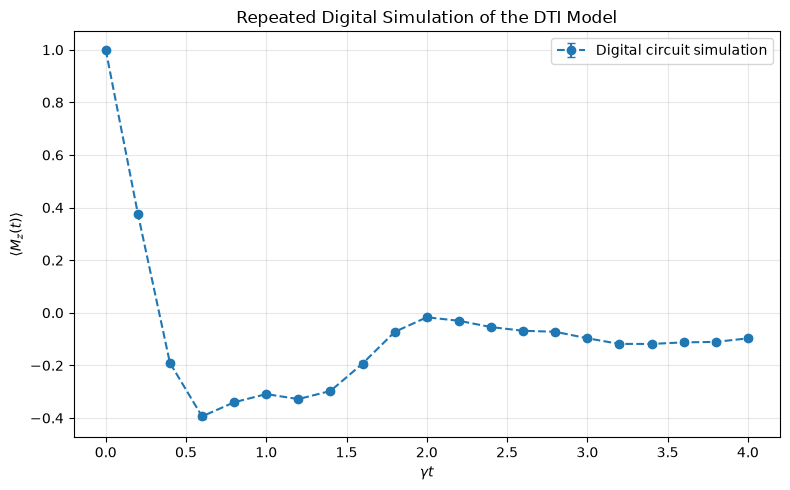


BASIC VALIDATION
----------------
Initial <Mz> = 1.000000
Final <Mz>   = -0.097168
Maximum SEM  = 0.008453

Exercise 5.5 complete.


In [5]:
# Exercise 5.5 — Repeated digital open-system evolution

# Uses from Exercise 5.4:
#
# append_dti_trotter()
# append_decay_channel()
# simulator
# J, Delta, gamma, dt
# theta_decay


# ------------------------------------------------------------
# 1. Simulation settings
# ------------------------------------------------------------

x_fixed = 0.4906

# Same range as Notebook 04:
#
# gamma * dt = 0.2
# gamma * t_max = 4
#
gamma_t_max = 4.0

n_steps_max = int(
    round(
        gamma_t_max
        / (gamma * dt)
    )
)

gamma_times_circuit = (
    np.arange(
        n_steps_max + 1
    )
    * gamma
    * dt
)

# Paper uses 8192 shots per data point
shots = 8192


# ------------------------------------------------------------
# 2. Build a circuit containing N complete MSSE steps
#
# Qubits:
#
# q0 = system spin 1
# q1 = system spin 2
# q2 = reusable ancilla
#
# Classical bits:
#
# c0 = ancilla measurement
# c1 = final spin 1
# c2 = final spin 2
#
# We reuse c0 after every ancilla measurement because
# we only need the final magnetisation, not the complete
# jump history.
# ------------------------------------------------------------

def build_msse_circuit(
    number_of_steps,
    x_value=0.4906
):

    qc = QuantumCircuit(
        3,
        3
    )

    # Initial system state is |00>
    #
    # Our convention:
    #
    # |0> = spin up
    #
    # therefore |00> = |up up>


    for step in range(
        number_of_steps
    ):

        # ----------------------------------------------------
        # A. Hamiltonian evolution before dissipation
        #
        # exp(-i x H dt)
        # ----------------------------------------------------

        append_dti_trotter(
            qc,
            0,
            1,
            x_value * dt
        )


        # ----------------------------------------------------
        # B. Decay channel for spin 1
        #
        # Measure ancilla into c0 and reset.
        # ----------------------------------------------------

        append_decay_channel(
            qc,
            system_qubit=0,
            ancilla_qubit=2,
            classical_bit=0
        )


        # ----------------------------------------------------
        # C. Decay channel for spin 2
        #
        # Same ancilla is reused.
        # ----------------------------------------------------

        append_decay_channel(
            qc,
            system_qubit=1,
            ancilla_qubit=2,
            classical_bit=0
        )


        # ----------------------------------------------------
        # D. Remaining Hamiltonian evolution
        #
        # exp[-i(1-x)Hdt]
        # ----------------------------------------------------

        append_dti_trotter(
            qc,
            0,
            1,
            (1.0 - x_value) * dt
        )


    # --------------------------------------------------------
    # Final measurement of system spins
    #
    # q0 -> c1
    # q1 -> c2
    # --------------------------------------------------------

    qc.measure(
        0,
        1
    )

    qc.measure(
        1,
        2
    )

    return qc


# ------------------------------------------------------------
# 3. Build one circuit for every time point
#
# Circuit 0:
#   measure initial state
#
# Circuit 1:
#   one MSSE step
#
# Circuit 2:
#   two MSSE steps
#
# etc.
# ------------------------------------------------------------

circuits = [
    build_msse_circuit(
        number_of_steps=n,
        x_value=x_fixed
    )
    for n in range(
        n_steps_max + 1
    )
]


print(
    "Number of time points:",
    len(circuits)
)

print(
    "Maximum number of MSSE steps:",
    n_steps_max
)


# ------------------------------------------------------------
# 4. Transpile all circuits
# ------------------------------------------------------------

print(
    "\nTranspiling circuits..."
)

compiled_circuits = transpile(
    circuits,
    simulator,
    optimization_level=1
)

print(
    "Transpilation complete."
)


# ------------------------------------------------------------
# 5. Run all circuits
# ------------------------------------------------------------

print(
    "\nRunning circuit simulation..."
)

job = simulator.run(
    compiled_circuits,
    shots=shots
)

results = job.result()

print(
    "Simulation complete."
)


# ------------------------------------------------------------
# 6. Function to calculate <Mz> from measurement counts
#
# Classical output:
#
# c2 c1 c0
#
# c2 = spin 2
# c1 = spin 1
# c0 = most recent ancilla result
#
# For each system qubit:
#
# |0> -> Z = +1
# |1> -> Z = -1
#
# Mz = (Z1 + Z2)/2
# ------------------------------------------------------------

def magnetisation_from_counts(
    counts,
    shots
):

    mz_sum = 0.0

    mz_squared_sum = 0.0


    for bitstring, count in counts.items():

        bits = bitstring.replace(
            " ",
            ""
        )

        # Qiskit prints:
        #
        # c2 c1 c0

        spin2 = int(
            bits[0]
        )

        spin1 = int(
            bits[1]
        )


        z1 = (
            +1
            if spin1 == 0
            else -1
        )

        z2 = (
            +1
            if spin2 == 0
            else -1
        )


        mz = (
            z1 + z2
        ) / 2


        mz_sum += (
            mz * count
        )

        mz_squared_sum += (
            mz**2 * count
        )


    mean_mz = (
        mz_sum
        / shots
    )


    mean_mz_squared = (
        mz_squared_sum
        / shots
    )


    variance = (
        mean_mz_squared
        - mean_mz**2
    )

    variance = max(
        variance,
        0.0
    )


    # Standard error of the mean
    sem = np.sqrt(
        variance
        / shots
    )


    return (
        mean_mz,
        sem
    )


# ------------------------------------------------------------
# 7. Extract magnetisation at every time
# ------------------------------------------------------------

Mz_circuit = []

Mz_circuit_sem = []


for i in range(
    len(circuits)
):

    counts = results.get_counts(
        i
    )

    mean_mz, sem_mz = (
        magnetisation_from_counts(
            counts,
            shots
        )
    )

    Mz_circuit.append(
        mean_mz
    )

    Mz_circuit_sem.append(
        sem_mz
    )


Mz_circuit = np.array(
    Mz_circuit
)

Mz_circuit_sem = np.array(
    Mz_circuit_sem
)


# ------------------------------------------------------------
# 8. Print results
# ------------------------------------------------------------

print(
    "\nEXERCISE 5.5 — REPEATED CIRCUIT EVOLUTION"
)

print(
    "-----------------------------------------"
)

print(
    f"x                     = "
    f"{x_fixed}"
)

print(
    f"gamma * dt            = "
    f"{gamma * dt}"
)

print(
    f"Shots per time point  = "
    f"{shots}"
)

print(
    f"Number of time points = "
    f"{len(gamma_times_circuit)}"
)


print(
    "\nMAGNETISATION"
)

print(
    "-------------"
)

print(
    f"{'gamma*t':>10}"
    f"{'<Mz>':>14}"
    f"{'SEM':>14}"
)

print(
    "-" * 38
)


for t, mz, sem in zip(
    gamma_times_circuit,
    Mz_circuit,
    Mz_circuit_sem
):

    print(
        f"{t:>10.2f}"
        f"{mz:>14.6f}"
        f"{sem:>14.6f}"
    )


# ------------------------------------------------------------
# 9. Plot gate-based dynamics
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.errorbar(
    gamma_times_circuit,
    Mz_circuit,
    yerr=Mz_circuit_sem,
    marker="o",
    linestyle="--",
    capsize=3,
    label="Digital circuit simulation"
)

plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$\langle M_z(t)\rangle$"
)

plt.title(
    "Repeated Digital Simulation of the DTI Model"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 10. Basic validation
# ------------------------------------------------------------

print(
    "\nBASIC VALIDATION"
)

print(
    "----------------"
)

print(
    f"Initial <Mz> = "
    f"{Mz_circuit[0]:.6f}"
)

print(
    f"Final <Mz>   = "
    f"{Mz_circuit[-1]:.6f}"
)

print(
    f"Maximum SEM  = "
    f"{np.max(Mz_circuit_sem):.6f}"
)

print(
    "\nExercise 5.5 complete."
)

5.6 Validate against Notebook 04

NOTEBOOK 05 — FINAL VALIDATION
------------------------------
Method                              RMSE         MAE     Max Error
------------------------------------------------------------------
MSSE x = 0.4906                 0.025819    0.020533      0.045196
Optimised MSSE                  0.023203    0.019331      0.040897
Digital circuit                 0.022984    0.019248      0.040840

CIRCUIT vs CLASSICAL MSSE
-------------------------
RMSE      = 0.018249
MAE       = 0.014367
Max error = 0.038080

APPROXIMATE ADDITIONAL CIRCUIT ERROR
------------------------------------
MSSE RMSE            = 0.025819
Circuit RMSE         = 0.022984
Difference in RMSE   = -0.002835


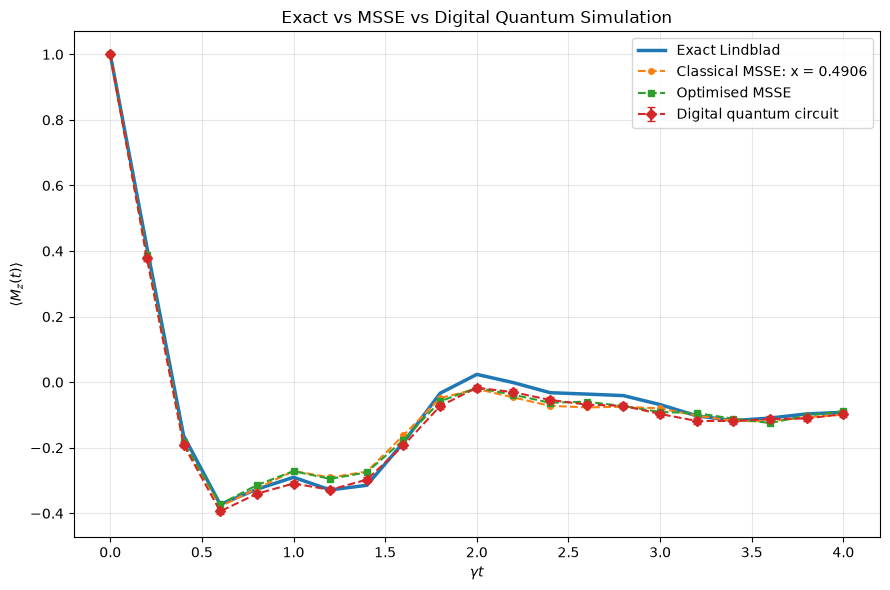

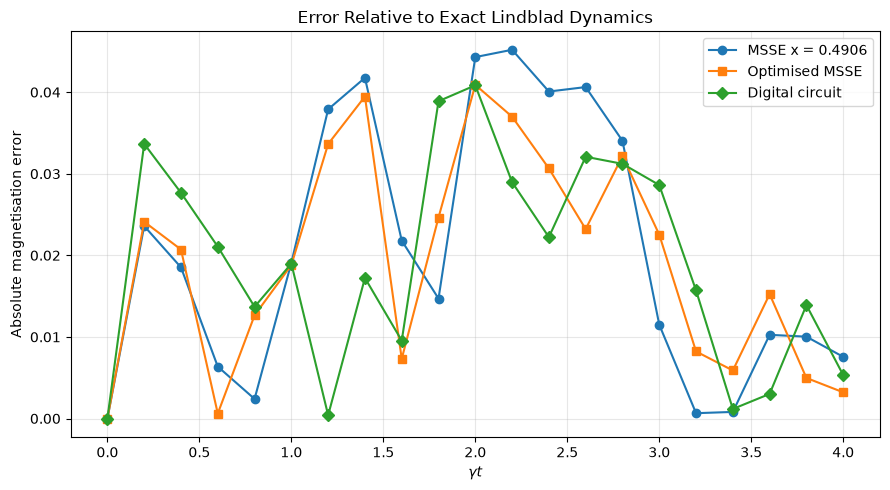


NOTEBOOK 05 VALIDATION SUMMARY
------------------------------
MSSE fixed-x RMSE      : 0.025819
Optimised MSSE RMSE    : 0.023203
Digital circuit RMSE   : 0.022984
Circuit vs MSSE RMSE   : 0.018249
Maximum circuit SEM    : 0.008453

Notebook 05 complete.


In [6]:
# Exercise 5.6 — Validate digital circuit against Notebook 04

from pathlib import Path


# ------------------------------------------------------------
# 1. Load Notebook 04 results
# ------------------------------------------------------------

data_path = Path(
    "../data/notebook04_results.npz"
)

if not data_path.exists():
    raise FileNotFoundError(
        "Notebook 04 results were not found.\n"
        "Run the export cell at the end of Notebook 04 first."
    )


data04 = np.load(
    data_path
)

gamma_times_04 = data04[
    "gamma_times"
]

Mz_exact_04 = data04[
    "exact_mz"
]

Mz_msse_fixed = data04[
    "fixed_04906_mz"
]

Mz_msse_optimised = data04[
    "optimised_mz"
]

Mz_msse_optimised_sem = data04[
    "optimised_sem"
]


# ------------------------------------------------------------
# 2. Check that the time grids match
# ------------------------------------------------------------

if not np.allclose(
    gamma_times_circuit,
    gamma_times_04
):
    raise ValueError(
        "Notebook 04 and Notebook 05 use different "
        "time grids."
    )


# ------------------------------------------------------------
# 3. General error function
# ------------------------------------------------------------

def error_metrics(
    approximation,
    reference
):
    """
    Return RMSE, MAE and maximum absolute error.
    """

    error = (
        approximation
        - reference
    )

    rmse = np.sqrt(
        np.mean(
            error**2
        )
    )

    mae = np.mean(
        np.abs(
            error
        )
    )

    max_error = np.max(
        np.abs(
            error
        )
    )

    return (
        rmse,
        mae,
        max_error
    )


# ------------------------------------------------------------
# 4. Compare all methods against exact Lindblad dynamics
# ------------------------------------------------------------

rmse_fixed, mae_fixed, max_fixed = (
    error_metrics(
        Mz_msse_fixed,
        Mz_exact_04
    )
)

rmse_opt, mae_opt, max_opt = (
    error_metrics(
        Mz_msse_optimised,
        Mz_exact_04
    )
)

rmse_circuit, mae_circuit, max_circuit = (
    error_metrics(
        Mz_circuit,
        Mz_exact_04
    )
)


# ------------------------------------------------------------
# 5. Compare quantum circuit directly with classical MSSE
#
# This helps isolate the additional error introduced when
# converting the MSSE algorithm into a gate circuit.
# ------------------------------------------------------------

rmse_circuit_vs_msse, \
mae_circuit_vs_msse, \
max_circuit_vs_msse = error_metrics(
    Mz_circuit,
    Mz_msse_fixed
)


# ------------------------------------------------------------
# 6. Print summary table
# ------------------------------------------------------------

print(
    "NOTEBOOK 05 — FINAL VALIDATION"
)

print(
    "------------------------------"
)

print(
    f"{'Method':<28}"
    f"{'RMSE':>12}"
    f"{'MAE':>12}"
    f"{'Max Error':>14}"
)

print(
    "-" * 66
)


print(
    f"{'MSSE x = 0.4906':<28}"
    f"{rmse_fixed:>12.6f}"
    f"{mae_fixed:>12.6f}"
    f"{max_fixed:>14.6f}"
)

print(
    f"{'Optimised MSSE':<28}"
    f"{rmse_opt:>12.6f}"
    f"{mae_opt:>12.6f}"
    f"{max_opt:>14.6f}"
)

print(
    f"{'Digital circuit':<28}"
    f"{rmse_circuit:>12.6f}"
    f"{mae_circuit:>12.6f}"
    f"{max_circuit:>14.6f}"
)


# ------------------------------------------------------------
# 7. Additional circuit implementation error
# ------------------------------------------------------------

print(
    "\nCIRCUIT vs CLASSICAL MSSE"
)

print(
    "-------------------------"
)

print(
    f"RMSE      = "
    f"{rmse_circuit_vs_msse:.6f}"
)

print(
    f"MAE       = "
    f"{mae_circuit_vs_msse:.6f}"
)

print(
    f"Max error = "
    f"{max_circuit_vs_msse:.6f}"
)


# ------------------------------------------------------------
# 8. Estimate extra error from circuit implementation
#
# This is only a simple numerical comparison, not a strict
# mathematical decomposition of the two error sources.
# ------------------------------------------------------------

additional_rmse = (
    rmse_circuit
    - rmse_fixed
)

print(
    "\nAPPROXIMATE ADDITIONAL CIRCUIT ERROR"
)

print(
    "------------------------------------"
)

print(
    f"MSSE RMSE            = "
    f"{rmse_fixed:.6f}"
)

print(
    f"Circuit RMSE         = "
    f"{rmse_circuit:.6f}"
)

print(
    f"Difference in RMSE   = "
    f"{additional_rmse:.6f}"
)


# ------------------------------------------------------------
# 9. Final comparison plot
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


# Exact Lindblad
plt.plot(
    gamma_times_04,
    Mz_exact_04,
    linewidth=2.5,
    label="Exact Lindblad"
)


# Classical MSSE
plt.plot(
    gamma_times_04,
    Mz_msse_fixed,
    marker="o",
    linestyle="--",
    markersize=4,
    label="Classical MSSE: x = 0.4906"
)


# Optimised MSSE
plt.plot(
    gamma_times_04,
    Mz_msse_optimised,
    marker="s",
    linestyle="--",
    markersize=4,
    label="Optimised MSSE"
)


# Gate-based digital simulation
plt.errorbar(
    gamma_times_circuit,
    Mz_circuit,
    yerr=Mz_circuit_sem,
    marker="D",
    linestyle="--",
    markersize=5,
    capsize=3,
    label="Digital quantum circuit"
)


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    r"$\langle M_z(t)\rangle$"
)

plt.title(
    "Exact vs MSSE vs Digital Quantum Simulation"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 10. Plot absolute errors
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)


plt.plot(
    gamma_times_04,
    np.abs(
        Mz_msse_fixed
        - Mz_exact_04
    ),
    marker="o",
    label="MSSE x = 0.4906"
)


plt.plot(
    gamma_times_04,
    np.abs(
        Mz_msse_optimised
        - Mz_exact_04
    ),
    marker="s",
    label="Optimised MSSE"
)


plt.plot(
    gamma_times_circuit,
    np.abs(
        Mz_circuit
        - Mz_exact_04
    ),
    marker="D",
    label="Digital circuit"
)


plt.xlabel(
    r"$\gamma t$"
)

plt.ylabel(
    "Absolute magnetisation error"
)

plt.title(
    "Error Relative to Exact Lindblad Dynamics"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 11. Final project summary
# ------------------------------------------------------------

print(
    "\nNOTEBOOK 05 VALIDATION SUMMARY"
)

print(
    "------------------------------"
)

print(
    f"MSSE fixed-x RMSE      : "
    f"{rmse_fixed:.6f}"
)

print(
    f"Optimised MSSE RMSE    : "
    f"{rmse_opt:.6f}"
)

print(
    f"Digital circuit RMSE   : "
    f"{rmse_circuit:.6f}"
)

print(
    f"Circuit vs MSSE RMSE   : "
    f"{rmse_circuit_vs_msse:.6f}"
)

print(
    f"Maximum circuit SEM    : "
    f"{np.max(Mz_circuit_sem):.6f}"
)

print(
    "\nNotebook 05 complete."
)